In [1]:
import os

folders = [
    "environment",
    "training",
    "models/dqn",
    "models/ppo",
    "models/reinforce",
    "results/dqn",
    "results/ppo",
    "results/reinforce",
    "logs/dqn",
    "logs/ppo",
    "logs/reinforce",
    "best_models/dqn",
    "best_models/ppo",
    "best_models/reinforce",
    "analysis"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

Project folders created.


In [2]:
%%writefile requirements.txt
gymnasium
stable-baselines3[extra]
pygame
imageio
imageio-ffmpeg
pandas

Writing requirements.txt


In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 11.0 MB/s eta 0:00:00


In [4]:
import os
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure

BASE_LOG_DIR = "logs"

def make_env(env_class, algo_name):
    log_dir = os.path.join(BASE_LOG_DIR, algo_name)
    os.makedirs(log_dir, exist_ok=True)

    env = env_class()
    env = Monitor(env, log_dir)

    logger = configure(log_dir, ["csv", "tensorboard"])

    return env, logger, log_dir

2026-04-04 14:06:10.518822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775311570.737524      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775311570.794436      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775311571.285980      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311571.286022      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311571.286025      55 computation_placer.cc:177] computation placer alr

In [5]:
%%writefile environment/rendering.py
import pygame


WINDOW_WIDTH = 1280
WINDOW_HEIGHT = 780
BACKGROUND = (242, 245, 247)
CARD = (255, 255, 255)
CARD_BORDER = (214, 220, 226)
TEXT = (32, 37, 43)
MUTED = (96, 108, 118)
GREEN = (76, 175, 80)
RED = (220, 80, 80)
YELLOW = (232, 181, 67)
BLUE = (90, 140, 220)
PURPLE = (145, 110, 215)
ORANGE = (237, 125, 49)
TEAL = (66, 166, 166)
SHADOW = (0, 0, 0, 18)


def _ensure_pygame():
    if not pygame.get_init():
        pygame.init()
        pygame.font.init()


def _draw_text(surface, text, x, y, font, color=TEXT):
    img = font.render(str(text), True, color)
    surface.blit(img, (x, y))


def _draw_shadowed_card(surface, rect, radius=18):
    shadow = pygame.Surface((rect.width, rect.height), pygame.SRCALPHA)
    pygame.draw.rect(shadow, SHADOW, shadow.get_rect(), border_radius=radius)
    surface.blit(shadow, (rect.x + 4, rect.y + 5))
    pygame.draw.rect(surface, CARD, rect, border_radius=radius)
    pygame.draw.rect(surface, CARD_BORDER, rect, width=1, border_radius=radius)


def _progress_color(ratio, reverse=False):
    if reverse:
        if ratio < 0.6:
            return GREEN
        if ratio < 0.9:
            return YELLOW
        return RED
    if ratio < 0.4:
        return RED
    if ratio < 0.75:
        return YELLOW
    return GREEN


def _draw_progress_bar(surface, x, y, w, h, label, value, max_value, font, reverse=False):
    ratio = 0.0 if max_value <= 0 else max(0.0, min(value / max_value, 1.0))
    color = _progress_color(ratio, reverse=reverse)
    _draw_text(surface, f"{label}: {value:.1f} / {max_value:.1f}", x, y, font)
    bar_y = y + 28
    pygame.draw.rect(surface, (232, 236, 240), (x, bar_y, w, h), border_radius=10)
    pygame.draw.rect(surface, color, (x, bar_y, int(w * ratio), h), border_radius=10)
    pygame.draw.rect(surface, CARD_BORDER, (x, bar_y, w, h), width=1, border_radius=10)


def _status_from_info(info, step):
    score = float(info.get("score", 0.0))
    quantities = info.get("quantities", [])
    if step == 0:
        return "READY", BLUE
    if sum(int(q) for q in quantities) == 0 and score <= 0:
        return "EMPTY", YELLOW
    return "IN PROGRESS", TEAL


def render_meal_state(info, step=0, save_path=None):
    _ensure_pygame()

    surface = pygame.Surface((WINDOW_WIDTH, WINDOW_HEIGHT))
    surface.fill(BACKGROUND)

    title_font = pygame.font.SysFont("arial", 30, bold=True)
    h2_font = pygame.font.SysFont("arial", 22, bold=True)
    text_font = pygame.font.SysFont("arial", 18)
    small_font = pygame.font.SysFont("arial", 15)
    big_font = pygame.font.SysFont("arial", 24, bold=True)

    scenario_name = info.get("scenario_name", "unknown_scenario")
    goal = info.get("goal", "unknown")
    condition = info.get("condition", "unknown")
    age_group = info.get("age_group", "unknown")
    score = float(info.get("score", 0.0))

    nutrition = info.get("nutrition", {})
    calories = float(nutrition.get("cal", 0.0))
    sodium = float(nutrition.get("sodium", 0.0))
    protein = float(nutrition.get("protein", 0.0))
    fiber = float(nutrition.get("fiber", 0.0))
    fat = float(nutrition.get("fat", 0.0))

    target_calories = float(info.get("target_calories", 500.0))
    max_sodium = float(info.get("max_sodium", 400.0))
    target_protein = float(info.get("target_protein", 25.0))
    target_fiber = float(info.get("target_fiber", 10.0))
    max_fat = float(info.get("max_fat", 25.0))
    min_diversity = int(info.get("min_diversity", 3))

    ingredient_names = info.get("ingredient_names", [])
    quantities = info.get("quantities", [])
    items = list(zip(ingredient_names, quantities))

    diversity = sum(1 for q in quantities if int(q) > 0)
    total_items = sum(int(q) for q in quantities)
    status, status_color = _status_from_info(info, step)

    _draw_text(surface, "Kitchen Meal Planning Environment", 34, 24, title_font)
    _draw_text(surface, f"Scenario: {scenario_name}", 36, 62, text_font, MUTED)

    pill = pygame.Rect(1030, 24, 210, 42)
    pygame.draw.rect(surface, status_color, pill, border_radius=20)
    label = text_font.render(status, True, (255, 255, 255))
    surface.blit(label, (pill.centerx - label.get_width() // 2, pill.y + 10))

    cards = [
        ("Goal", goal.replace("_", " "), BLUE),
        ("Condition", condition.replace("_", " "), TEAL),
        ("Age Group", age_group.replace("_", " "), ORANGE),
        ("Step", str(step), PURPLE),
    ]
    x = 34
    y = 100
    widths = [240, 240, 220, 140]
    for i, (title, value, accent) in enumerate(cards):
        rect = pygame.Rect(x, y, widths[i], 92)
        _draw_shadowed_card(surface, rect)
        pygame.draw.rect(surface, accent, (rect.x, rect.y, 8, rect.height), border_radius=18)
        _draw_text(surface, title, rect.x + 22, rect.y + 16, small_font, MUTED)
        _draw_text(surface, value, rect.x + 22, rect.y + 42, big_font if i != 3 else text_font)
        x += widths[i] + 18

    rect = pygame.Rect(34, 220, 560, 520)
    _draw_shadowed_card(surface, rect)
    _draw_text(surface, "Nutrition Dashboard", rect.x + 22, rect.y + 18, h2_font)
    _draw_text(surface, f"Score: {score:.2f}   |   Diversity: {diversity}/{min_diversity}   |   Portions: {total_items}", rect.x + 22, rect.y + 48, small_font, MUTED)

    x = rect.x + 22
    y = rect.y + 90
    w = 510
    _draw_progress_bar(surface, x, y, w, 22, "Calories", calories, target_calories, text_font)
    _draw_progress_bar(surface, x, y + 88, w, 22, "Sodium", sodium, max_sodium, text_font, reverse=True)
    _draw_progress_bar(surface, x, y + 176, w, 22, "Protein", protein, target_protein, text_font)
    _draw_progress_bar(surface, x, y + 264, w, 22, "Fiber", fiber, target_fiber, text_font)
    _draw_progress_bar(surface, x, y + 352, w, 22, "Fat", fat, max_fat, text_font, reverse=True)

    score_color = GREEN if score >= 0 else RED
    _draw_text(surface, f"Meal score: {score:.2f}", x, rect.bottom - 54, big_font, score_color)

    rect = pygame.Rect(622, 220, 624, 520)
    _draw_shadowed_card(surface, rect)
    _draw_text(surface, "Ingredient Quantities", rect.x + 22, rect.y + 18, h2_font)
    _draw_text(surface, "Expanded ingredient set for more realistic meals", rect.x + 22, rect.y + 48, small_font, MUTED)

    x = rect.x + 22
    y = rect.y + 86
    col_w = 280
    row_h = 70

    for i, (name, qty) in enumerate(items):
        col = i % 2
        row = i // 2
        card_x = x + col * (col_w + 18)
        card_y = y + row * row_h
        item_rect = pygame.Rect(card_x, card_y, col_w, 54)
        pygame.draw.rect(surface, (245, 248, 251), item_rect, border_radius=16)
        pygame.draw.rect(surface, CARD_BORDER, item_rect, width=1, border_radius=16)

        badge_color = GREEN if int(qty) > 0 else (210, 215, 220)
        badge_rect = pygame.Rect(card_x + 194, card_y + 12, 70, 30)
        pygame.draw.rect(surface, badge_color, badge_rect, border_radius=15)

        _draw_text(surface, name, card_x + 16, card_y + 15, text_font)
        qty_text = text_font.render(f"qty {int(qty)}", True, (255, 255, 255) if int(qty) > 0 else TEXT)
        surface.blit(qty_text, (badge_rect.centerx - qty_text.get_width() // 2, badge_rect.y + 6))

    _draw_text(surface, "Used by env.render(), random play, and screenshot capture.", 34, 752, small_font, MUTED)

    if save_path:
        pygame.image.save(surface, save_path)

    return surface


Writing environment/rendering.py


In [6]:
%%writefile environment/custom_env.py
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from environment.rendering import render_meal_state


class KitchenMealPlanningEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, max_steps=18):
        super().__init__()
        self.max_steps = max_steps
        self.max_quantity = 3

        # Per-portion approximations. Simplified but intentionally diverse.
        self.ingredients = [
            {"name": "rice", "group": "carb", "baby_ok": True,  "cal": 130, "protein": 2.7, "carbs": 28.0, "fat": 0.3, "fiber": 0.4, "sodium": 1},
            {"name": "beans", "group": "protein", "baby_ok": True,  "cal": 127, "protein": 8.7, "carbs": 22.8, "fat": 0.5, "fiber": 6.4, "sodium": 2},
            {"name": "chicken", "group": "protein", "baby_ok": True,  "cal": 165, "protein": 31.0, "carbs": 0.0, "fat": 3.6, "fiber": 0.0, "sodium": 74},
            {"name": "egg", "group": "protein", "baby_ok": True,  "cal": 78,  "protein": 6.3, "carbs": 0.6, "fat": 5.3, "fiber": 0.0, "sodium": 62},
            {"name": "yogurt", "group": "dairy", "baby_ok": True,  "cal": 59,  "protein": 10.0, "carbs": 3.6, "fat": 0.4, "fiber": 0.0, "sodium": 36},
            {"name": "milk", "group": "dairy", "baby_ok": True,  "cal": 61,  "protein": 3.2, "carbs": 4.8, "fat": 3.3, "fiber": 0.0, "sodium": 43},
            {"name": "cabbage", "group": "vegetable", "baby_ok": True,  "cal": 25,  "protein": 1.3, "carbs": 5.8, "fat": 0.1, "fiber": 2.5, "sodium": 18},
            {"name": "carrot", "group": "vegetable", "baby_ok": True,  "cal": 41,  "protein": 0.9, "carbs": 10.0, "fat": 0.2, "fiber": 2.8, "sodium": 69},
            {"name": "spinach", "group": "vegetable", "baby_ok": True,  "cal": 23,  "protein": 2.9, "carbs": 3.6, "fat": 0.4, "fiber": 2.2, "sodium": 79},
            {"name": "sweet_potato", "group": "carb", "baby_ok": True,  "cal": 86,  "protein": 1.6, "carbs": 20.1, "fat": 0.1, "fiber": 3.0, "sodium": 55},
            {"name": "banana", "group": "fruit", "baby_ok": True,  "cal": 89,  "protein": 1.1, "carbs": 23.0, "fat": 0.3, "fiber": 2.6, "sodium": 1},
            {"name": "avocado", "group": "fat", "baby_ok": True,  "cal": 160, "protein": 2.0, "carbs": 8.5, "fat": 14.7, "fiber": 6.7, "sodium": 7},
            {"name": "oil", "group": "fat", "baby_ok": False, "cal": 119, "protein": 0.0, "carbs": 0.0, "fat": 13.5, "fiber": 0.0, "sodium": 0},
            {"name": "soy_sauce", "group": "seasoning", "baby_ok": False, "cal": 9, "protein": 1.3, "carbs": 0.8, "fat": 0.0, "fiber": 0.1, "sodium": 879},
        ]

        self.num_ingredients = len(self.ingredients)
        self.name_to_idx = {ing["name"]: i for i, ing in enumerate(self.ingredients)}

        self.goals = ["weight_loss", "weight_gain", "maintenance", "baby_safe"]
        self.conditions = ["none", "hypertension", "baby"]
        self.age_groups = ["adult", "infant"]

        self.scenarios = [
            {
                "name": "adult_weight_loss",
                "goal": "weight_loss",
                "condition": "none",
                "age_group": "adult",
                "target_calories": 450,
                "max_sodium": 500,
                "target_protein": 30,
                "target_fiber": 12,
                "max_fat": 22,
                "max_items": 5,
                "min_diversity": 3,
                "required_groups": ["protein", "vegetable"],
                "forbidden": [],
                "preferred_templates": ["lean_plate", "light_bowl"],
                "banned_templates": ["sauce_heavy"],
            },
            {
                "name": "adult_weight_gain",
                "goal": "weight_gain",
                "condition": "none",
                "age_group": "adult",
                "target_calories": 700,
                "max_sodium": 700,
                "target_protein": 38,
                "target_fiber": 10,
                "max_fat": 35,
                "max_items": 6,
                "min_diversity": 3,
                "required_groups": ["protein", "carb", "vegetable"],
                "forbidden": [],
                "preferred_templates": ["gain_plate", "protein_bowl"],
                "banned_templates": ["sauce_heavy"],
            },
            {
                "name": "adult_hypertension",
                "goal": "maintenance",
                "condition": "hypertension",
                "age_group": "adult",
                "target_calories": 500,
                "max_sodium": 350,
                "target_protein": 28,
                "target_fiber": 12,
                "max_fat": 25,
                "max_items": 5,
                "min_diversity": 3,
                "required_groups": ["protein", "vegetable", "fruit_or_carb"],
                "forbidden": ["soy_sauce"],
                "preferred_templates": ["hypertension_plate", "light_bowl"],
                "banned_templates": ["sauce_heavy"],
            },
            {
                "name": "baby_meal",
                "goal": "baby_safe",
                "condition": "baby",
                "age_group": "infant",
                "target_calories": 280,
                "max_sodium": 120,
                "target_protein": 12,
                "target_fiber": 5,
                "max_fat": 12,
                "max_items": 4,
                "min_diversity": 3,
                "required_groups": ["protein", "vegetable", "fruit_or_carb"],
                "forbidden": ["soy_sauce", "oil"],
                "preferred_templates": ["baby_soft_meal", "baby_breakfast"],
                "banned_templates": ["sauce_heavy"],
            },
        ]

        # Meal templates discourage single-food exploitation and encourage plate-like meals.
        self.meal_templates = {
            "lean_plate": {
                "members": ["chicken", "carrot", "spinach", "rice", "sweet_potato"],
                "required_any": [["chicken", "beans", "egg", "yogurt"], ["carrot", "spinach", "cabbage"]],
                "bonus": 2.0,
            },
            "light_bowl": {
                "members": ["beans", "rice", "cabbage", "carrot", "banana"],
                "required_any": [["beans", "chicken", "egg"], ["cabbage", "carrot", "spinach"]],
                "bonus": 2.0,
            },
            "gain_plate": {
                "members": ["rice", "chicken", "beans", "avocado", "cabbage", "sweet_potato"],
                "required_any": [["rice", "sweet_potato"], ["chicken", "beans", "egg"], ["cabbage", "carrot", "spinach"]],
                "bonus": 2.8,
            },
            "protein_bowl": {
                "members": ["beans", "egg", "yogurt", "rice", "banana"],
                "required_any": [["beans", "egg", "yogurt"], ["rice", "banana", "sweet_potato"]],
                "bonus": 2.0,
            },
            "hypertension_plate": {
                "members": ["rice", "beans", "banana", "spinach", "cabbage", "chicken"],
                "required_any": [["beans", "chicken", "egg", "yogurt"], ["spinach", "cabbage", "carrot"], ["banana", "rice", "sweet_potato"]],
                "bonus": 2.5,
            },
            "baby_soft_meal": {
                "members": ["sweet_potato", "banana", "yogurt", "egg", "carrot", "rice"],
                "required_any": [["sweet_potato", "rice", "banana"], ["yogurt", "egg", "beans"], ["carrot", "banana"]],
                "bonus": 3.4,
            },
            "baby_breakfast": {
                "members": ["banana", "yogurt", "milk", "egg", "rice"],
                "required_any": [["banana", "rice"], ["yogurt", "milk", "egg"]],
                "bonus": 3.0,
            },
            "sauce_heavy": {
                "members": ["soy_sauce", "oil"],
                "required_any": [["soy_sauce"], ["oil"]],
                "bonus": -4.0,
            },
        }

        self.action_space = spaces.Discrete(self.num_ingredients * 2 + 1)

        obs_size = (
            self.num_ingredients
            + 6
            + len(self.goals)
            + len(self.conditions)
            + len(self.age_groups)
            + 5
            + 4
        )

        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(obs_size,),
            dtype=np.float32,
        )

        self.quantities = None
        self.current_step = 0
        self.last_score = 0.0
        self.current_scenario = None
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.quantities = np.zeros(self.num_ingredients, dtype=np.int32)
        self.current_step = 0

        if options is not None and "scenario_name" in options:
            scenario_name = options["scenario_name"]
            matched = [s for s in self.scenarios if s["name"] == scenario_name]
            self.current_scenario = matched[0] if matched else self.scenarios[np.random.randint(len(self.scenarios))]
        else:
            self.current_scenario = self.scenarios[np.random.randint(len(self.scenarios))]

        self.last_score = self._meal_score()
        return self._get_obs(), self._get_info()

    def step(self, action):
        self.current_step += 1
        terminated = False
        truncated = False
        old_quantities = self.quantities.copy()

        if action < self.num_ingredients:
            idx = action
            if self.quantities[idx] < self.max_quantity:
                self.quantities[idx] += 1
        elif action < self.num_ingredients * 2:
            idx = action - self.num_ingredients
            if self.quantities[idx] > 0:
                self.quantities[idx] -= 1
        else:
            terminated = True

        new_score = self._meal_score()
        reward = new_score - self.last_score
        self.last_score = new_score

        reward -= 0.03

        if np.array_equal(old_quantities, self.quantities) and not terminated:
            reward -= 0.30

        if not terminated and self._near_good_meal():
            reward -= 0.18

        if terminated:
            reward += self._final_bonus()

        if self.current_step >= self.max_steps:
            truncated = True
            reward -= 0.80

        return self._get_obs(), float(reward), terminated, truncated, self._get_info()

    def _get_obs(self):
        n = self._nutrition()
        sc = self.current_scenario

        quantities_norm = self.quantities / self.max_quantity
        nutrition_norm = np.array([
            min(n["cal"] / 1000.0, 1.0),
            min(n["protein"] / 80.0, 1.0),
            min(n["carbs"] / 180.0, 1.0),
            min(n["fat"] / 60.0, 1.0),
            min(n["fiber"] / 40.0, 1.0),
            min(n["sodium"] / 2000.0, 1.0),
        ], dtype=np.float32)

        goal_vec = np.zeros(len(self.goals), dtype=np.float32)
        goal_vec[self.goals.index(sc["goal"])] = 1.0

        cond_vec = np.zeros(len(self.conditions), dtype=np.float32)
        cond_vec[self.conditions.index(sc["condition"])] = 1.0

        age_vec = np.zeros(len(self.age_groups), dtype=np.float32)
        age_vec[self.age_groups.index(sc["age_group"])] = 1.0

        targets = np.array([
            sc["target_calories"] / 1000.0,
            sc["max_sodium"] / 2000.0,
            sc["target_protein"] / 80.0,
            sc["target_fiber"] / 40.0,
            sc["max_fat"] / 60.0,
        ], dtype=np.float32)

        meal_meta = np.array([
            min(self._diversity() / 5.0, 1.0),
            min(np.sum(self.quantities) / max(sc["max_items"], 1), 1.0),
            min(self._template_match_score() / 4.0, 1.0),
            min(self.current_step / self.max_steps, 1.0),
        ], dtype=np.float32)

        return np.concatenate([
            quantities_norm.astype(np.float32),
            nutrition_norm,
            goal_vec,
            cond_vec,
            age_vec,
            targets,
            meal_meta,
        ]).astype(np.float32)

    def _nutrition(self):
        totals = {"cal": 0.0, "protein": 0.0, "carbs": 0.0, "fat": 0.0, "fiber": 0.0, "sodium": 0.0}
        for q, ing in zip(self.quantities, self.ingredients):
            totals["cal"] += q * ing["cal"]
            totals["protein"] += q * ing["protein"]
            totals["carbs"] += q * ing["carbs"]
            totals["fat"] += q * ing["fat"]
            totals["fiber"] += q * ing["fiber"]
            totals["sodium"] += q * ing["sodium"]
        return totals

    def _diversity(self):
        return int(np.sum(self.quantities > 0))

    def _present_groups(self):
        return {ing["group"] for q, ing in zip(self.quantities, self.ingredients) if q > 0}

    def _ingredient_index(self, name):
        return self.name_to_idx[name]

    def _repetition_penalty(self):
        penalty = 0.0
        for q in self.quantities:
            if q > 1:
                penalty += (q - 1) * 1.0
            if q > 2:
                penalty += (q - 2) * 2.0
        return penalty

    def _single_food_penalty(self):
        diversity = self._diversity()
        total_items = int(np.sum(self.quantities))
        if total_items >= 2 and diversity == 1:
            return 8.0
        if total_items >= 3 and diversity == 2:
            return 2.5
        return 0.0

    def _scenario_forbidden_penalty(self):
        sc = self.current_scenario
        penalty = 0.0
        for forbidden_name in sc.get("forbidden", []):
            idx = self._ingredient_index(forbidden_name)
            penalty += self.quantities[idx] * 6.0
        return penalty

    def _baby_unsuitable_penalty(self):
        if self.current_scenario["condition"] != "baby":
            return 0.0

        penalty = 0.0
        for q, ing in zip(self.quantities, self.ingredients):
            if q > 0 and not ing["baby_ok"]:
                penalty += q * 7.0

        # Baby meals should not be dominated by one or two ingredients.
        for limited_name in ["beans", "yogurt", "milk"]:
            idx = self._ingredient_index(limited_name)
            if self.quantities[idx] > 1:
                penalty += (self.quantities[idx] - 1) * 2.8

        if self.quantities[self._ingredient_index("banana")] > 1:
            penalty += (self.quantities[self._ingredient_index("banana")] - 1) * 1.8

        return penalty

    def _group_bonus(self):
        sc = self.current_scenario
        present_groups = self._present_groups()
        bonus = 0.0

        for req in sc.get("required_groups", []):
            if req == "fruit_or_carb":
                if "fruit" in present_groups or "carb" in present_groups:
                    bonus += 1.5
            elif req in present_groups:
                bonus += 1.5

        return bonus

    def _missing_required_group_penalty(self):
        sc = self.current_scenario
        present_groups = self._present_groups()
        penalty = 0.0

        for req in sc.get("required_groups", []):
            if req == "fruit_or_carb":
                if "fruit" not in present_groups and "carb" not in present_groups:
                    penalty += 3.0
            elif req not in present_groups:
                penalty += 3.0

        return penalty

    def _diversity_bonus(self):
        sc = self.current_scenario
        diversity = self._diversity()

        if diversity >= sc["min_diversity"]:
            return 3.5
        if diversity == sc["min_diversity"] - 1:
            return 1.0
        return -3.0

    def _target_alignment(self, value, target, tolerance, weight):
        diff = abs(value - target)
        return max(0.0, weight * (1.0 - diff / max(tolerance, 1e-6)))

    def _macro_balance_bonus(self, nutrition):
        sc = self.current_scenario
        bonus = 0.0
        bonus += self._target_alignment(
            min(nutrition["protein"], sc["target_protein"]),
            sc["target_protein"],
            max(sc["target_protein"], 1.0),
            3.2,
        )
        bonus += self._target_alignment(
            min(nutrition["fiber"], sc["target_fiber"]),
            sc["target_fiber"],
            max(sc["target_fiber"], 1.0),
            2.7,
        )
        return bonus

    def _calorie_score(self, nutrition):
        sc = self.current_scenario
        return self._target_alignment(
            nutrition["cal"],
            sc["target_calories"],
            sc["target_calories"] * 0.16,
            7.5,
        )

    def _safety_score(self, nutrition):
        sc = self.current_scenario
        score = 0.0

        if nutrition["sodium"] <= sc["max_sodium"]:
            score += 2.0
        else:
            score -= (nutrition["sodium"] - sc["max_sodium"]) * 0.06

        if nutrition["fat"] <= sc["max_fat"]:
            score += 1.0
        else:
            score -= (nutrition["fat"] - sc["max_fat"]) * 0.40

        return score

    def _portion_penalty(self):
        sc = self.current_scenario
        total_items = int(np.sum(self.quantities))
        if total_items <= sc["max_items"]:
            return 0.0
        return (total_items - sc["max_items"]) * 2.5

    def _template_satisfied(self, template_name):
        template = self.meal_templates[template_name]
        present = {ing["name"] for q, ing in zip(self.quantities, self.ingredients) if q > 0}

        # Must include at least 2 items from members and satisfy all required_any clauses.
        member_hits = len([name for name in template["members"] if name in present])
        if member_hits < 2:
            return False

        for clause in template["required_any"]:
            if not any(name in present for name in clause):
                return False

        return True

    def _template_match_score(self):
        sc = self.current_scenario
        score = 0.0

        for template_name in sc.get("preferred_templates", []):
            if self._template_satisfied(template_name):
                score += self.meal_templates[template_name]["bonus"]

        for template_name in sc.get("banned_templates", []):
            if self._template_satisfied(template_name):
                score += self.meal_templates[template_name]["bonus"]

        return score

    def _scenario_specific_adjustment(self, nutrition):
        sc = self.current_scenario
        adjustment = 0.0
        present_groups = self._present_groups()

        if sc["goal"] == "weight_loss":
            if nutrition["cal"] > sc["target_calories"] * 1.08:
                adjustment -= (nutrition["cal"] - sc["target_calories"] * 1.08) / 18.0
            if "vegetable" in present_groups:
                adjustment += 0.8

        elif sc["goal"] == "weight_gain":
            if nutrition["cal"] < sc["target_calories"] * 0.90:
                adjustment -= (sc["target_calories"] * 0.90 - nutrition["cal"]) / 20.0
            if nutrition["protein"] >= sc["target_protein"]:
                adjustment += 1.6
            if "carb" in present_groups:
                adjustment += 0.9

        elif sc["goal"] == "maintenance":
            adjustment -= abs(nutrition["cal"] - sc["target_calories"]) / 100.0
            if sc["condition"] == "hypertension":
                adjustment -= nutrition["sodium"] * 0.015
                if self.quantities[self._ingredient_index("soy_sauce")] > 0:
                    adjustment -= 8.0

        elif sc["goal"] == "baby_safe":
            if nutrition["cal"] > 320:
                adjustment -= (nutrition["cal"] - 320) / 12.0
            if nutrition["protein"] >= 8:
                adjustment += 1.2
            for name in ["banana", "carrot", "sweet_potato", "yogurt", "egg", "rice", "milk"]:
                idx = self._ingredient_index(name)
                if self.quantities[idx] > 0:
                    adjustment += 0.7

        return adjustment

    def _meal_score(self):
        nutrition = self._nutrition()
        total_items = int(np.sum(self.quantities))

        if total_items == 0:
            return -3.5

        score = 0.0
        score += self._calorie_score(nutrition)
        score += self._macro_balance_bonus(nutrition)
        score += self._safety_score(nutrition)
        score += self._group_bonus()
        score += self._diversity_bonus()
        score += self._template_match_score()
        score += self._scenario_specific_adjustment(nutrition)

        score -= self._missing_required_group_penalty()
        score -= self._repetition_penalty()
        score -= self._single_food_penalty()
        score -= self._portion_penalty()
        score -= self._scenario_forbidden_penalty()
        score -= self._baby_unsuitable_penalty()

        return score

    def _near_good_meal(self):
        nutrition = self._nutrition()
        sc = self.current_scenario
        diversity = self._diversity()
        present_groups = self._present_groups()

        required_ok = True
        for req in sc.get("required_groups", []):
            if req == "fruit_or_carb":
                if "fruit" not in present_groups and "carb" not in present_groups:
                    required_ok = False
            elif req not in present_groups:
                required_ok = False

        return (
            abs(nutrition["cal"] - sc["target_calories"]) <= sc["target_calories"] * 0.10
            and nutrition["sodium"] <= sc["max_sodium"]
            and nutrition["fat"] <= sc["max_fat"]
            and diversity >= sc["min_diversity"]
            and required_ok
            and self._repetition_penalty() <= 1.5
            and self._single_food_penalty() == 0
        )

    def _final_bonus(self):
        nutrition = self._nutrition()
        sc = self.current_scenario
        total_items = int(np.sum(self.quantities))
        diversity = self._diversity()

        if total_items == 0:
            return -7.0

        bonus = 0.0

        if total_items <= sc["max_items"]:
            bonus += 2.0
        if diversity >= sc["min_diversity"]:
            bonus += 3.0
        if self._missing_required_group_penalty() == 0:
            bonus += 3.0
        if nutrition["sodium"] <= sc["max_sodium"]:
            bonus += 2.0
        if nutrition["fat"] <= sc["max_fat"]:
            bonus += 1.0
        if abs(nutrition["cal"] - sc["target_calories"]) <= sc["target_calories"] * 0.10:
            bonus += 3.0
        if nutrition["protein"] >= sc["target_protein"] * 0.85:
            bonus += 2.0
        if nutrition["fiber"] >= sc["target_fiber"] * 0.85:
            bonus += 1.5
        if self._repetition_penalty() <= 1.0:
            bonus += 1.5
        if self._single_food_penalty() == 0:
            bonus += 2.0
        if self._template_match_score() > 0:
            bonus += 2.0

        return bonus

    def _get_info(self):
        return {
            "scenario_name": self.current_scenario["name"],
            "goal": self.current_scenario["goal"],
            "condition": self.current_scenario["condition"],
            "age_group": self.current_scenario["age_group"],
            "target_calories": self.current_scenario["target_calories"],
            "max_sodium": self.current_scenario["max_sodium"],
            "target_protein": self.current_scenario["target_protein"],
            "target_fiber": self.current_scenario["target_fiber"],
            "max_fat": self.current_scenario["max_fat"],
            "min_diversity": self.current_scenario["min_diversity"],
            "quantities": self.quantities.copy(),
            "nutrition": self._nutrition(),
            "score": self.last_score,
            "ingredient_names": [x["name"] for x in self.ingredients],
        }

    def render(self, save_path=None):
        info = self._get_info()
        return render_meal_state(info, step=self.current_step, save_path=save_path)


Writing environment/custom_env.py


In [7]:
%%writefile training/dqn_training.py
import json
import numpy as np

import os
import sys


PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.logger import configure

from environment.custom_env import KitchenMealPlanningEnv

sys.path.append(os.path.abspath("."))

SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]


def make_env(log_dir):
    env = KitchenMealPlanningEnv(max_steps=20)
    env = Monitor(env, log_dir)  
    return env


def evaluate_on_scenario(model, scenario_name, n_episodes=10):
    rewards = []

    for _ in range(n_episodes):
        env = KitchenMealPlanningEnv(max_steps=20)
        obs, info = env.reset(options={"scenario_name": scenario_name})

        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(int(action))
            total_reward += reward

        rewards.append(total_reward)

    return {
        "scenario": scenario_name,
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "min_reward": float(np.min(rewards)),
        "max_reward": float(np.max(rewards)),
    }


def main():
    os.makedirs("models/dqn", exist_ok=True)
    os.makedirs("best_models/dqn", exist_ok=True)
    os.makedirs("logs/dqn", exist_ok=True)
    os.makedirs("results/dqn", exist_ok=True)

    log_dir = "logs/dqn/"

    train_env = make_env(log_dir)
    eval_env = make_env(log_dir)
    logger = logger = configure(log_dir, ["csv", "tensorboard"])

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path="best_models/dqn",
        log_path="logs/dqn/eval",
        eval_freq=5000,
        n_eval_episodes=10,
        deterministic=True,
        render=False,
    )

    model = DQN(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=5e-4,
        buffer_size=20000,
        learning_starts=500,
        batch_size=64,
        tau=1.0,
        gamma=0.99,
        train_freq=4,
        gradient_steps=1,
        target_update_interval=500,
        exploration_fraction=0.4,
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        verbose=1,
        tensorboard_log="logs/dqn",
        device="auto",
    )

    model.set_logger(logger)
    model.learn(
        total_timesteps=50000,
        callback=eval_callback,
        progress_bar=True,
    )

    model.save("models/dqn/kitchen_dqn_model")

    final_model = DQN.load("models/dqn/kitchen_dqn_model")
    best_model_path = "best_models/dqn/best_model.zip"

    models_to_test = {
        "final_model": final_model
    }

    if os.path.exists(best_model_path):
        models_to_test["best_model"] = DQN.load(best_model_path)

    all_results = {}

    for model_name, loaded_model in models_to_test.items():
        print(f"\n===== Evaluating {model_name} =====")
        scenario_results = []

        for scenario in SCENARIOS:
            result = evaluate_on_scenario(loaded_model, scenario, n_episodes=10)
            scenario_results.append(result)

            print(
                f"{scenario}: "
                f"mean={result['mean_reward']:.2f}, "
                f"std={result['std_reward']:.2f}, "
                f"min={result['min_reward']:.2f}, "
                f"max={result['max_reward']:.2f}"
            )

        overall_mean = float(np.mean([r["mean_reward"] for r in scenario_results]))
        all_results[model_name] = {
            "overall_mean_reward": overall_mean,
            "scenario_results": scenario_results,
        }

        print(f"Overall mean reward for {model_name}: {overall_mean:.2f}")

    with open("results/dqn/dqn_eval_results.json", "w") as f:
        json.dump(all_results, f, indent=2)

    print("\nSaved evaluation results to results/dqn/dqn_eval_results.json")


if __name__ == "__main__":
    main()

Writing training/dqn_training.py


In [8]:
!python training/dqn_training.py

2026-04-04 14:06:33.510571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775311593.533405     120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775311593.540683     120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775311593.560499     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311593.560529     120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311593.560533     120 computation_placer.cc:177] computation placer alr

In [9]:
from environment.custom_env import KitchenMealPlanningEnv

env = KitchenMealPlanningEnv()
obs, info = env.reset()

print("obs shape:", obs.shape)
print("obs space:", env.observation_space.shape)
print("num ingredients:", env.num_ingredients)
print("ingredient names:", [x["name"] for x in env.ingredients])

obs shape: (38,)
obs space: (38,)
num ingredients: 14
ingredient names: ['rice', 'beans', 'chicken', 'egg', 'yogurt', 'milk', 'cabbage', 'carrot', 'spinach', 'sweet_potato', 'banana', 'avocado', 'oil', 'soy_sauce']


In [10]:
from stable_baselines3 import DQN
from environment.custom_env import KitchenMealPlanningEnv

env = KitchenMealPlanningEnv()
model = DQN.load("best_models/dqn/best_model.zip")

obs, info = env.reset(options={"scenario_name": "adult_hypertension"})
done = False
truncated = False
total_reward = 0

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(int(action))
    total_reward += reward
    env.render()
    print("Reward:", reward)
    print("=" * 50)

print("Total reward:", total_reward)

error: XDG_RUNTIME_DIR not set in the environment.


Reward: -2.2899999999999996
Reward: -8.489999999999998
Reward: 14.5125
Reward: 2.734999999999999
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: -8.085
Reward: 8.025000000000002
Reward: 6.059999999999999
Total reward: 20.19250000000001


In [11]:
%%writefile random_play.py
import os
from environment.custom_env import KitchenMealPlanningEnv

os.makedirs("results/random_frames", exist_ok=True)

env = KitchenMealPlanningEnv(max_steps=12)
obs, info = env.reset(options={"scenario_name": "adult_weight_loss"})

done = False
truncated = False
step = 0
total_reward = 0.0

while not (done or truncated):
    env.render(save_path=f"results/random_frames/frame_{step:03d}.png")

    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)

    total_reward += reward
    step += 1

env.render(save_path=f"results/random_frames/frame_{step:03d}.png")

print("Random demo complete.")
print("Frames saved in results/random_frames/")
print("Total reward:", total_reward)

Writing random_play.py


In [12]:
!python random_play.py

error: XDG_RUNTIME_DIR not set in the environment.
Random demo complete.
Frames saved in results/random_frames/
Total reward: -92.21766666666667


In [13]:
%%writefile training/ppo_training.py
import os
import json
import numpy as np

import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

from environment.custom_env import KitchenMealPlanningEnv
from stable_baselines3.common.logger import configure



SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]


def make_env(log_dir):
    env = KitchenMealPlanningEnv(max_steps=20)
    env = Monitor(env, log_dir)
    return env


def evaluate_on_scenario(model, scenario_name, n_episodes=10):
    rewards = []

    for _ in range(n_episodes):
        env = KitchenMealPlanningEnv(max_steps=20)
        obs, info = env.reset(options={"scenario_name": scenario_name})

        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(int(action))
            total_reward += reward

        rewards.append(total_reward)

    return {
        "scenario": scenario_name,
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "min_reward": float(np.min(rewards)),
        "max_reward": float(np.max(rewards)),
    }


def main():
    os.makedirs("models/ppo", exist_ok=True)
    os.makedirs("best_models/ppo", exist_ok=True)
    os.makedirs("logs/ppo", exist_ok=True)
    os.makedirs("results/ppo", exist_ok=True)


    log_dir = "logs/ppo/"
    
    train_env = make_env(log_dir)
    eval_env = make_env(log_dir)
    
    logger = configure(log_dir, ["csv", "tensorboard"])
    
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path="best_models/ppo",
        log_path="logs/ppo/eval",
        eval_freq=5000,
        n_eval_episodes=10,
        deterministic=True,
        render=False,
    )

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=1,
        tensorboard_log="logs/ppo",
        device="auto",
    )

    model.set_logger(logger)
    model.learn(
        total_timesteps=50000,
        callback=eval_callback,
        progress_bar=True,
    )

    model.save("models/ppo/kitchen_ppo_model")

    final_model = PPO.load("models/ppo/kitchen_ppo_model")
    best_model_path = "best_models/ppo/best_model.zip"

    models_to_test = {
        "final_model": final_model
    }

    if os.path.exists(best_model_path):
        models_to_test["best_model"] = PPO.load(best_model_path)

    all_results = {}

    for model_name, loaded_model in models_to_test.items():
        print(f"\n===== Evaluating {model_name} =====")
        scenario_results = []

        for scenario in SCENARIOS:
            result = evaluate_on_scenario(loaded_model, scenario, n_episodes=10)
            scenario_results.append(result)

            print(
                f"{scenario}: "
                f"mean={result['mean_reward']:.2f}, "
                f"std={result['std_reward']:.2f}, "
                f"min={result['min_reward']:.2f}, "
                f"max={result['max_reward']:.2f}"
            )

        overall_mean = float(np.mean([r["mean_reward"] for r in scenario_results]))
        all_results[model_name] = {
            "overall_mean_reward": overall_mean,
            "scenario_results": scenario_results,
        }

        print(f"Overall mean reward for {model_name}: {overall_mean:.2f}")

    with open("results/ppo/ppo_eval_results.json", "w") as f:
        json.dump(all_results, f, indent=2)

    print("\nSaved evaluation results to results/ppo/ppo_eval_results.json")


if __name__ == "__main__":
    main()

Writing training/ppo_training.py


In [14]:
!python training/ppo_training.py

2026-04-04 14:08:38.115920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775311718.138954     157 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775311718.147552     157 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775311718.167265     157 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311718.167294     157 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775311718.167298     157 computation_placer.cc:177] computation placer alr

In [15]:
from stable_baselines3 import PPO
from environment.custom_env import KitchenMealPlanningEnv

env = KitchenMealPlanningEnv()
model = PPO.load("best_models/ppo/best_model.zip")

obs, info = env.reset(options={"scenario_name": "adult_hypertension"})
done = False
truncated = False
total_reward = 0

while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(int(action))
    total_reward += reward
    env.render()
    print("Reward:", reward)
    print("=" * 50)

print("Total reward:", total_reward)

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Reward: -4.346428571428572
Reward: 12.144285714285717
Reward: 12.161071428571429
Reward: 1.811785714285713
Reward: 8.103214285714289
Reward: 20.97
Total reward: 50.84392857142857


In [16]:
%%writefile training/reinforce_training.py
import os
import sys
import json
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from environment.custom_env import KitchenMealPlanningEnv


SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]


class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.distributions.Categorical(logits=logits)


def make_env():
    return KitchenMealPlanningEnv(max_steps=20)


def run_episode(env, policy, device, deterministic=False, scenario_name=None):
    if scenario_name is not None:
        obs, info = env.reset(options={"scenario_name": scenario_name})
    else:
        obs, info = env.reset()

    log_probs = []
    rewards = []
    entropies = []

    done = False
    truncated = False
    total_reward = 0.0

    while not (done or truncated):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        dist = policy(obs_tensor)

        if deterministic:
            action = torch.argmax(dist.probs, dim=1).item()
            log_prob = torch.log(dist.probs[0, action] + 1e-8)
            entropy = dist.entropy().mean()
        else:
            action_tensor = dist.sample()
            action = action_tensor.item()
            log_prob = dist.log_prob(action_tensor).squeeze()
            entropy = dist.entropy().mean()

        obs, reward, done, truncated, info = env.step(int(action))

        log_probs.append(log_prob)
        rewards.append(float(reward))
        entropies.append(entropy)
        total_reward += reward

    return log_probs, rewards, entropies, total_reward, info


def compute_returns(rewards, gamma, device):
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32, device=device)

    if len(returns) > 1 and torch.std(returns) > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns


def evaluate_on_scenario(policy, device, scenario_name, n_episodes=5):
    rewards = []

    for _ in range(n_episodes):
        env = make_env()
        _, _, _, total_reward, _ = run_episode(
            env=env,
            policy=policy,
            device=device,
            deterministic=True,
            scenario_name=scenario_name,
        )
        rewards.append(total_reward)

    return float(np.mean(rewards))

def save_model(policy, path, obs_dim, action_dim):
    clean_payload = {
        "state_dict": {k: v.detach().cpu() for k, v in policy.state_dict().items()},
        "obs_dim": int(obs_dim),
        "action_dim": int(action_dim),
    }
    torch.save(clean_payload, path)


def load_model(path, device):
    payload = torch.load(path, map_location=device)

    # CASE 1: New format (correct)
    if isinstance(payload, dict) and "state_dict" in payload:
        obs_dim = int(payload["obs_dim"])
        action_dim = int(payload["action_dim"])
        state_dict = payload["state_dict"]

    # CASE 2: Old format (weights only)
    else:
        env = KitchenMealPlanningEnv()
        obs, _ = env.reset()

        obs_dim = int(obs.shape[0])
        action_dim = int(env.action_space.n)
        state_dict = payload

    model = PolicyNetwork(obs_dim, action_dim).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    return model
    
def main():
    os.makedirs("models/reinforce", exist_ok=True)
    os.makedirs("best_models/reinforce", exist_ok=True)
    os.makedirs("logs/reinforce", exist_ok=True)
    os.makedirs("results/reinforce", exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    temp_env = make_env()
    obs, _ = temp_env.reset()
    obs_dim = int(obs.shape[0])
    action_dim = int(temp_env.action_space.n)

    policy = PolicyNetwork(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=1e-3)

    num_episodes = 3000
    gamma = 0.99
    entropy_coef = 0.001
    eval_freq = 200

    #  LOG STORAGE
    reward_log = []
    loss_log = []
    entropy_log = []
    eval_log = []

    best_score = -math.inf

    for episode in range(1, num_episodes + 1):
        env = make_env()

        log_probs, rewards, entropies, total_reward, _ = run_episode(
            env, policy, device
        )

        returns = compute_returns(rewards, gamma, device)

        policy_loss_terms = []
        entropy_terms = []

        for log_prob, G, entropy in zip(log_probs, returns, entropies):
            policy_loss_terms.append(-log_prob * G)
            entropy_terms.append(entropy)

        policy_loss = torch.stack(policy_loss_terms).sum()
        entropy_bonus = torch.stack(entropy_terms).mean()

        loss = policy_loss - entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        #  SAVE LOGS
        reward_log.append(total_reward)
        loss_log.append(loss.item())
        entropy_log.append(entropy_bonus.item())

        # PRINT
        if episode % 50 == 0:
            print(f"Episode {episode} | Reward: {total_reward:.2f}")

        #  EVALUATION LOG (VERY IMPORTANT)
        if episode % eval_freq == 0:
            scores = []

            for scenario in SCENARIOS:
                score = evaluate_on_scenario(policy, device, scenario)
                scores.append(score)

            mean_score = float(np.mean(scores))

            eval_log.append({
                "episode": episode,
                "mean_reward": mean_score
            })

            print(f"[EVAL] Episode {episode} → Mean Reward: {mean_score:.2f}")

            if mean_score > best_score:
                best_score = mean_score
                torch.save(policy.state_dict(), "best_models/reinforce/best_model.pt")

    #  SAVE FINAL MODEL
    save_model(policy, "best_models/reinforce/best_model.pt", obs_dim, action_dim)  
    # SAVE CSV FILES (THIS IS WHAT YOU WERE MISSING)

    pd.DataFrame({
        "episode": list(range(1, len(reward_log) + 1)),
        "reward": reward_log
    }).to_csv("logs/reinforce/monitor.csv", index=False)

    pd.DataFrame({
        "episode": list(range(1, len(loss_log) + 1)),
        "loss": loss_log,
        "entropy": entropy_log
    }).to_csv("logs/reinforce/progress.csv", index=False)

    pd.DataFrame(eval_log).to_csv("logs/reinforce/eval.csv", index=False)

    print("Logs saved (monitor.csv, progress.csv, eval.csv)")


if __name__ == "__main__":
    main()

Writing training/reinforce_training.py


In [17]:
!python training/reinforce_training.py

Episode 50 | Reward: -40.79
Episode 100 | Reward: -53.28
Episode 150 | Reward: 16.30
Episode 200 | Reward: 19.02
[EVAL] Episode 200 → Mean Reward: -16.50
Episode 250 | Reward: -24.16
Episode 300 | Reward: -78.53
Episode 350 | Reward: 11.18
Episode 400 | Reward: -10.01
[EVAL] Episode 400 → Mean Reward: -7.40
Episode 450 | Reward: 10.10
Episode 500 | Reward: -40.56
Episode 550 | Reward: 2.10
Episode 600 | Reward: 13.97
[EVAL] Episode 600 → Mean Reward: -18.53
Episode 650 | Reward: 8.42
Episode 700 | Reward: 12.09
Episode 750 | Reward: 11.31
Episode 800 | Reward: 7.85
[EVAL] Episode 800 → Mean Reward: -10.49
Episode 850 | Reward: 16.84
Episode 900 | Reward: 13.87
Episode 950 | Reward: 11.33
Episode 1000 | Reward: 3.10
[EVAL] Episode 1000 → Mean Reward: -18.23
Episode 1050 | Reward: 1.28
Episode 1100 | Reward: 4.69
Episode 1150 | Reward: 4.13
Episode 1200 | Reward: 7.43
[EVAL] Episode 1200 → Mean Reward: -19.11
Episode 1250 | Reward: 6.19
Episode 1300 | Reward: 8.51
Episode 1350 | Reward: 

In [18]:
import os
import sys
import torch

sys.path.append(os.path.abspath("."))

from environment.custom_env import KitchenMealPlanningEnv
from training.reinforce_training import load_model as load_reinforce

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = KitchenMealPlanningEnv()
model = load_reinforce("best_models/reinforce/best_model.pt", device)

obs, info = env.reset(options={"scenario_name": "adult_hypertension"})
done = False
truncated = False
total_reward = 0

while not (done or truncated):
    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
    dist = model(obs_tensor)
    action = torch.argmax(dist.probs, dim=1).item()

    obs, reward, done, truncated, info = env.step(int(action))
    total_reward += reward
    env.render()
    print("Reward:", reward)
    print("=" * 50)

print("Total reward:", total_reward)

Reward: -2.3557142857142854
Reward: -5.535714285714286
Reward: 15.563571428571429
Reward: 13.916607142857146
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -0.32999999999999996
Reward: -1.13
Total reward: 16.168750000000028


In [19]:
%%writefile training/dqn_experiments.py
import os
import sys
import json
import csv
import numpy as np

sys.path.append(os.path.abspath("."))

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

from environment.custom_env import KitchenMealPlanningEnv


SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]

DQN_EXPERIMENTS = [
    {"name": "dqn_exp_01", "learning_rate": 1e-3, "gamma": 0.95, "buffer_size": 10000, "batch_size": 32, "exploration_fraction": 0.30, "target_update_interval": 500},
    {"name": "dqn_exp_02", "learning_rate": 5e-4, "gamma": 0.95, "buffer_size": 10000, "batch_size": 64, "exploration_fraction": 0.30, "target_update_interval": 500},
    {"name": "dqn_exp_03", "learning_rate": 1e-4, "gamma": 0.95, "buffer_size": 10000, "batch_size": 64, "exploration_fraction": 0.30, "target_update_interval": 500},
    {"name": "dqn_exp_04", "learning_rate": 5e-4, "gamma": 0.99, "buffer_size": 10000, "batch_size": 64, "exploration_fraction": 0.30, "target_update_interval": 500},
    {"name": "dqn_exp_05", "learning_rate": 5e-4, "gamma": 0.99, "buffer_size": 20000, "batch_size": 64, "exploration_fraction": 0.40, "target_update_interval": 500},
    {"name": "dqn_exp_06", "learning_rate": 5e-4, "gamma": 0.99, "buffer_size": 20000, "batch_size": 128, "exploration_fraction": 0.40, "target_update_interval": 500},
    {"name": "dqn_exp_07", "learning_rate": 3e-4, "gamma": 0.99, "buffer_size": 30000, "batch_size": 64, "exploration_fraction": 0.40, "target_update_interval": 250},
    {"name": "dqn_exp_08", "learning_rate": 3e-4, "gamma": 0.99, "buffer_size": 30000, "batch_size": 64, "exploration_fraction": 0.20, "target_update_interval": 250},
    {"name": "dqn_exp_09", "learning_rate": 1e-4, "gamma": 0.995, "buffer_size": 30000, "batch_size": 128, "exploration_fraction": 0.20, "target_update_interval": 250},
    {"name": "dqn_exp_10", "learning_rate": 7e-4, "gamma": 0.98, "buffer_size": 15000, "batch_size": 64, "exploration_fraction": 0.35, "target_update_interval": 750},
]


def make_env():
    env = KitchenMealPlanningEnv(max_steps=20)
    env = Monitor(env)
    return env


def evaluate_on_scenario(model, scenario_name, n_episodes=5):
    rewards = []

    for _ in range(n_episodes):
        env = KitchenMealPlanningEnv(max_steps=20)
        obs, _ = env.reset(options={"scenario_name": scenario_name})

        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, _ = env.step(int(action))
            total_reward += reward

        rewards.append(total_reward)

    return float(np.mean(rewards))


def run_experiment(config, total_timesteps=30000):
    train_env = make_env()
    eval_env = make_env()

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"best_models/dqn/{config['name']}",
        log_path=f"logs/dqn/{config['name']}",
        eval_freq=5000,
        n_eval_episodes=5,
        deterministic=True,
        render=False,
    )

    model = DQN(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=config["learning_rate"],
        buffer_size=config["buffer_size"],
        learning_starts=500,
        batch_size=config["batch_size"],
        tau=1.0,
        gamma=config["gamma"],
        train_freq=4,
        gradient_steps=1,
        target_update_interval=config["target_update_interval"],
        exploration_fraction=config["exploration_fraction"],
        exploration_initial_eps=1.0,
        exploration_final_eps=0.05,
        verbose=0,
        tensorboard_log="logs/dqn",
        device="auto",
    )

    model.learn(total_timesteps=total_timesteps, callback=eval_callback, progress_bar=False)

    model_dir = f"models/dqn/{config['name']}"
    os.makedirs(model_dir, exist_ok=True)
    model.save(f"{model_dir}/model")

    scenario_scores = {}
    for scenario in SCENARIOS:
        scenario_scores[scenario] = evaluate_on_scenario(model, scenario, n_episodes=5)

    overall_mean = float(np.mean(list(scenario_scores.values())))

    result = {
        **config,
        "overall_mean_reward": overall_mean,
        **scenario_scores,
    }
    return result


def main():
    os.makedirs("models/dqn", exist_ok=True)
    os.makedirs("best_models/dqn", exist_ok=True)
    os.makedirs("logs/dqn", exist_ok=True)
    os.makedirs("results/dqn", exist_ok=True)

    results = []

    for config in DQN_EXPERIMENTS:
        print(f"Running {config['name']} ...")
        result = run_experiment(config)
        results.append(result)
        print(result)

    json_path = "results/dqn/dqn_hyperparameter_results.json"
    csv_path = "results/dqn/dqn_hyperparameter_results.csv"

    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)

    fieldnames = list(results[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)

    print(f"Saved JSON to {json_path}")
    print(f"Saved CSV to {csv_path}")


if __name__ == "__main__":
    main()

Writing training/dqn_experiments.py


In [20]:
!python training/dqn_experiments.py

2026-04-04 14:14:29.916598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775312069.940040     199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775312069.947615     199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775312069.967669     199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312069.967705     199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312069.967709     199 computation_placer.cc:177] computation placer alr

In [21]:
%%writefile training/ppo_experiments.py
import os
import sys
import json
import csv
import numpy as np

sys.path.append(os.path.abspath("."))

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

from environment.custom_env import KitchenMealPlanningEnv


SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]

PPO_EXPERIMENTS = [
    {"name": "ppo_exp_01", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_02", "learning_rate": 1e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_03", "learning_rate": 5e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_04", "learning_rate": 3e-4, "gamma": 0.95, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_05", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 2048, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_06", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 128, "ent_coef": 0.01, "clip_range": 0.2},
    {"name": "ppo_exp_07", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.001, "clip_range": 0.2},
    {"name": "ppo_exp_08", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.02, "clip_range": 0.2},
    {"name": "ppo_exp_09", "learning_rate": 3e-4, "gamma": 0.99, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "clip_range": 0.1},
    {"name": "ppo_exp_10", "learning_rate": 3e-4, "gamma": 0.995, "n_steps": 2048, "batch_size": 128, "ent_coef": 0.005, "clip_range": 0.25},
]


def make_env():
    env = KitchenMealPlanningEnv(max_steps=20)
    env = Monitor(env)
    return env


def evaluate_on_scenario(model, scenario_name, n_episodes=5):
    rewards = []

    for _ in range(n_episodes):
        env = KitchenMealPlanningEnv(max_steps=20)
        obs, _ = env.reset(options={"scenario_name": scenario_name})

        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, _ = env.step(int(action))
            total_reward += reward

        rewards.append(total_reward)

    return float(np.mean(rewards))


def run_experiment(config, total_timesteps=30000):
    train_env = make_env()
    eval_env = make_env()

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"best_models/ppo/{config['name']}",
        log_path=f"logs/ppo/{config['name']}",
        eval_freq=5000,
        n_eval_episodes=5,
        deterministic=True,
        render=False,
    )

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=config["learning_rate"],
        n_steps=config["n_steps"],
        batch_size=config["batch_size"],
        n_epochs=10,
        gamma=config["gamma"],
        gae_lambda=0.95,
        clip_range=config["clip_range"],
        ent_coef=config["ent_coef"],
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=0,
        tensorboard_log="logs/ppo",
        device="auto",
    )

    model.learn(total_timesteps=total_timesteps, callback=eval_callback, progress_bar=False)

    model_dir = f"models/ppo/{config['name']}"
    os.makedirs(model_dir, exist_ok=True)
    model.save(f"{model_dir}/model")

    scenario_scores = {}
    for scenario in SCENARIOS:
        scenario_scores[scenario] = evaluate_on_scenario(model, scenario, n_episodes=5)

    overall_mean = float(np.mean(list(scenario_scores.values())))

    result = {
        **config,
        "overall_mean_reward": overall_mean,
        **scenario_scores,
    }
    return result


def main():
    os.makedirs("models/ppo", exist_ok=True)
    os.makedirs("best_models/ppo", exist_ok=True)
    os.makedirs("logs/ppo", exist_ok=True)
    os.makedirs("results/ppo", exist_ok=True)

    results = []

    for config in PPO_EXPERIMENTS:
        print(f"Running {config['name']} ...")
        result = run_experiment(config)
        results.append(result)
        print(result)

    json_path = "results/ppo/ppo_hyperparameter_results.json"
    csv_path = "results/ppo/ppo_hyperparameter_results.csv"

    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)

    fieldnames = list(results[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)

    print(f"Saved JSON to {json_path}")
    print(f"Saved CSV to {csv_path}")


if __name__ == "__main__":
    main()

Writing training/ppo_experiments.py


In [22]:
!python training/ppo_experiments.py

2026-04-04 14:25:03.312128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775312703.335634     232 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775312703.344394     232 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775312703.365934     232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312703.365994     232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775312703.366001     232 computation_placer.cc:177] computation placer alr

In [23]:
%%writefile training/reinforce_experiments.py
import os
import sys
import json
import csv
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.abspath("."))

from environment.custom_env import KitchenMealPlanningEnv


SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]

REINFORCE_EXPERIMENTS = [
    {"name": "reinforce_exp_01", "learning_rate": 1e-3, "gamma": 0.99, "entropy_coef": 0.001},
    {"name": "reinforce_exp_02", "learning_rate": 5e-4, "gamma": 0.99, "entropy_coef": 0.001},
    {"name": "reinforce_exp_03", "learning_rate": 1e-4, "gamma": 0.99, "entropy_coef": 0.001},
    {"name": "reinforce_exp_04", "learning_rate": 1e-3, "gamma": 0.95, "entropy_coef": 0.001},
    {"name": "reinforce_exp_05", "learning_rate": 1e-3, "gamma": 0.995, "entropy_coef": 0.001},
    {"name": "reinforce_exp_06", "learning_rate": 1e-3, "gamma": 0.99, "entropy_coef": 0.0},
    {"name": "reinforce_exp_07", "learning_rate": 1e-3, "gamma": 0.99, "entropy_coef": 0.005},
    {"name": "reinforce_exp_08", "learning_rate": 5e-4, "gamma": 0.95, "entropy_coef": 0.005},
    {"name": "reinforce_exp_09", "learning_rate": 5e-4, "gamma": 0.995, "entropy_coef": 0.0005},
    {"name": "reinforce_exp_10", "learning_rate": 1e-4, "gamma": 0.995, "entropy_coef": 0.005},
]


class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim),
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.distributions.Categorical(logits=logits)


def make_env():
    return KitchenMealPlanningEnv(max_steps=20)


def run_episode(env, policy, device, deterministic=False, scenario_name=None):
    if scenario_name is not None:
        obs, info = env.reset(options={"scenario_name": scenario_name})
    else:
        obs, info = env.reset()

    log_probs = []
    rewards = []
    entropies = []

    done = False
    truncated = False
    total_reward = 0.0

    while not (done or truncated):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        dist = policy(obs_tensor)

        if deterministic:
            action = torch.argmax(dist.probs, dim=1).item()
            log_prob = torch.log(dist.probs[0, action] + 1e-8)
            entropy = dist.entropy().mean()
        else:
            action_tensor = dist.sample()
            action = action_tensor.item()
            log_prob = dist.log_prob(action_tensor).squeeze()
            entropy = dist.entropy().mean()

        obs, reward, done, truncated, info = env.step(int(action))

        log_probs.append(log_prob)
        rewards.append(float(reward))
        entropies.append(entropy)
        total_reward += reward

    return log_probs, rewards, entropies, total_reward


def compute_returns(rewards, gamma, device):
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32, device=device)
    if len(returns) > 1 and torch.std(returns) > 1e-8:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


def evaluate_on_scenario(policy, device, scenario_name, n_episodes=5):
    rewards = []

    for _ in range(n_episodes):
        env = make_env()
        _, _, _, total_reward = run_episode(
            env=env,
            policy=policy,
            device=device,
            deterministic=True,
            scenario_name=scenario_name,
        )
        rewards.append(total_reward)

    return float(np.mean(rewards))


def run_experiment(config, num_episodes=1500):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    temp_env = make_env()
    obs, _ = temp_env.reset()
    obs_dim = obs.shape[0]
    action_dim = temp_env.action_space.n

    policy = PolicyNetwork(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=config["learning_rate"])

    gamma = config["gamma"]
    entropy_coef = config["entropy_coef"]

    for episode in range(1, num_episodes + 1):
        env = make_env()
        log_probs, rewards, entropies, total_reward = run_episode(env, policy, device)

        returns = compute_returns(rewards, gamma, device)
        policy_loss_terms = []
        entropy_terms = []

        for log_prob, G, entropy in zip(log_probs, returns, entropies):
            policy_loss_terms.append(-log_prob * G)
            entropy_terms.append(entropy)

        policy_loss = torch.stack(policy_loss_terms).sum()
        entropy_bonus = torch.stack(entropy_terms).mean()
        loss = policy_loss - entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.0)
        optimizer.step()

    scenario_scores = {}
    for scenario in SCENARIOS:
        scenario_scores[scenario] = evaluate_on_scenario(policy, device, scenario, n_episodes=5)

    overall_mean = float(np.mean(list(scenario_scores.values())))

    model_dir = f"models/reinforce/{config['name']}"
    os.makedirs(model_dir, exist_ok=True)
    torch.save({
        "state_dict": policy.state_dict(),
        "obs_dim": obs_dim,
        "action_dim": action_dim,
    }, f"{model_dir}/model.pt")

    result = {
        **config,
        "overall_mean_reward": overall_mean,
        **scenario_scores,
    }
    return result


def main():
    os.makedirs("models/reinforce", exist_ok=True)
    os.makedirs("results/reinforce", exist_ok=True)

    results = []

    for config in REINFORCE_EXPERIMENTS:
        print(f"Running {config['name']} ...")
        result = run_experiment(config)
        results.append(result)
        print(result)

    json_path = "results/reinforce/reinforce_hyperparameter_results.json"
    csv_path = "results/reinforce/reinforce_hyperparameter_results.csv"

    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)

    fieldnames = list(results[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)

    print(f"Saved JSON to {json_path}")
    print(f"Saved CSV to {csv_path}")


if __name__ == "__main__":
    main()

Writing training/reinforce_experiments.py


In [24]:
!python training/reinforce_experiments.py

Running reinforce_exp_01 ...
{'name': 'reinforce_exp_01', 'learning_rate': 0.001, 'gamma': 0.99, 'entropy_coef': 0.001, 'overall_mean_reward': -16.369145363408514, 'adult_weight_loss': -5.044000000000003, 'adult_weight_gain': -27.05210526315787, 'adult_hypertension': -15.097142857142856, 'baby_meal': -18.28333333333332}
Running reinforce_exp_02 ...
{'name': 'reinforce_exp_02', 'learning_rate': 0.0005, 'gamma': 0.99, 'entropy_coef': 0.001, 'overall_mean_reward': -15.063187030075182, 'adult_weight_loss': -10.703500000000002, 'adult_weight_gain': -27.05210526315787, 'adult_hypertension': -15.097142857142856, 'baby_meal': -7.4}
Running reinforce_exp_03 ...
{'name': 'reinforce_exp_03', 'learning_rate': 0.0001, 'gamma': 0.99, 'entropy_coef': 0.001, 'overall_mean_reward': -24.169966165413523, 'adult_weight_loss': -13.596499999999997, 'adult_weight_gain': -44.896578947368404, 'adult_hypertension': -22.426785714285685, 'baby_meal': -15.760000000000002}
Running reinforce_exp_04 ...
{'name': 'rei

In [25]:
%%writefile analysis/plot_results.py
import pandas as pd
import matplotlib.pyplot as plt

dqn = pd.read_csv("results/dqn/dqn_hyperparameter_results.csv")
ppo = pd.read_csv("results/ppo/ppo_hyperparameter_results.csv")
reinforce = pd.read_csv("results/reinforce/reinforce_hyperparameter_results.csv")

# Overall comparison
plt.figure()
plt.bar(
    ["DQN", "PPO", "REINFORCE"],
    [
        dqn["overall_mean_reward"].max(),
        ppo["overall_mean_reward"].max(),
        reinforce["overall_mean_reward"].max(),
    ]
)
plt.title("Best Algorithm Comparison")
plt.ylabel("Mean Reward")
plt.savefig("results/overall_comparison.png")
plt.show()

# Example: learning rate effect (DQN)
plt.figure()
plt.scatter(dqn["learning_rate"], dqn["overall_mean_reward"])
plt.title("DQN Learning Rate vs Reward")
plt.xlabel("Learning Rate")
plt.ylabel("Reward")
plt.savefig("results/dqn_lr_plot.png")
plt.show()

Writing analysis/plot_results.py


In [26]:
!python analysis/plot_results.py

Figure(640x480)
Figure(640x480)


In [27]:
%%writefile main.py
import os
import sys
import torch

sys.path.append(os.path.abspath("."))

from stable_baselines3 import DQN, PPO
from environment.custom_env import KitchenMealPlanningEnv
from training.reinforce_training import load_model as load_reinforce


def load_dqn():
    env = KitchenMealPlanningEnv()
    model = DQN.load("best_models/dqn/best_model.zip")
    return env, model


def load_ppo():
    env = KitchenMealPlanningEnv()
    model = PPO.load("best_models/ppo/best_model.zip")
    return env, model


def load_reinforce_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    env = KitchenMealPlanningEnv()
    model = load_reinforce("best_models/reinforce/best_model.pt", device)
    return env, model, device


def main():
    os.makedirs("results/demo_frames", exist_ok=True)

    algorithm = "ppo"  # choose: "dqn", "ppo", "reinforce"
    scenario = "adult_hypertension"

    if algorithm == "dqn":
        env, model = load_dqn()
        device = None
    elif algorithm == "ppo":
        env, model = load_ppo()
        device = None
    elif algorithm == "reinforce":
        env, model, device = load_reinforce_model()
    else:
        raise ValueError("Invalid algorithm. Choose from dqn, ppo, reinforce.")

    obs, info = env.reset(options={"scenario_name": scenario})
    done = False
    truncated = False
    total_reward = 0.0
    step = 0

    print(f"\nRunning {algorithm.upper()} on {scenario}\n")

    while not (done or truncated):
        env.render(save_path=f"results/demo_frames/frame_{step:03d}.png")

        if algorithm in ["dqn", "ppo"]:
            action, _ = model.predict(obs, deterministic=True)
        else:
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            dist = model(obs_tensor)
            action = torch.argmax(dist.probs, dim=1).item()

        obs, reward, done, truncated, info = env.step(int(action))
        total_reward += reward

        print(f"Step {step} | Reward: {reward:.4f}")
        print(f"Nutrition: {info['nutrition']}")
        print(f"Quantities: {info['quantities']}")
        print("-" * 60)

        step += 1

    env.render(save_path=f"results/demo_frames/frame_{step:03d}.png")

    print("\nFinal Total Reward:", total_reward)
    print("Frames saved in results/demo_frames/")


if __name__ == "__main__":
    main()

Writing main.py


In [28]:
!python main.py

2026-04-04 14:52:30.299669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775314350.323261     293 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775314350.330707     293 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775314350.350695     293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775314350.350723     293 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775314350.350726     293 computation_placer.cc:177] computation placer alr

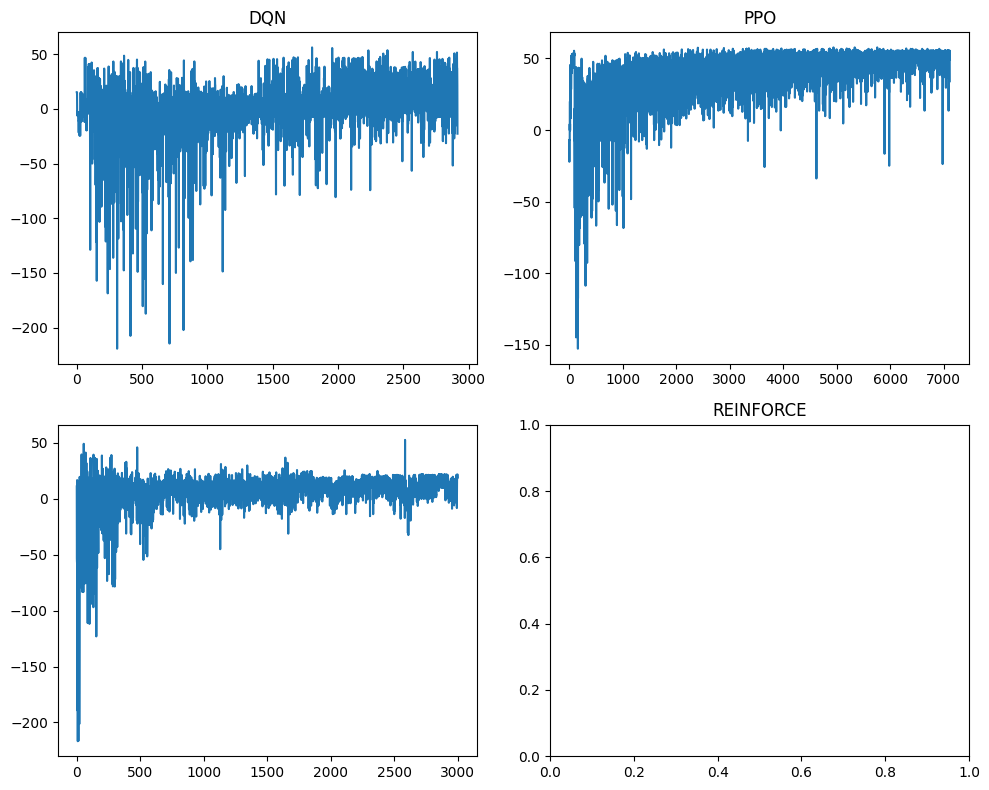

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

def load_rewards(path):
    df = pd.read_csv(path, skiprows=1)
    return df["r"]

dqn_r = load_rewards("logs/dqn/monitor.csv")
ppo_r = load_rewards("logs/ppo/monitor.csv")
reinforce_r = pd.read_csv("logs/reinforce/monitor.csv")["reward"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(dqn_r); axs[0,0].set_title("DQN")
axs[0,1].plot(ppo_r); axs[0,1].set_title("PPO")
axs[1,0].plot(reinforce_r); axs[1,1].set_title("REINFORCE")

plt.tight_layout()
plt.show()

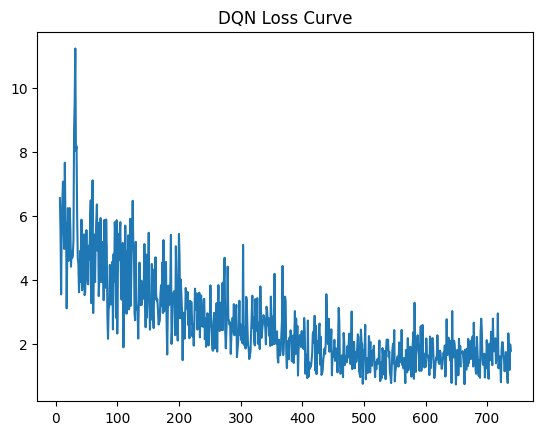

In [69]:
df = pd.read_csv("logs/dqn/progress.csv")

plt.plot(df["train/loss"])
plt.title("DQN Loss Curve")
plt.show()

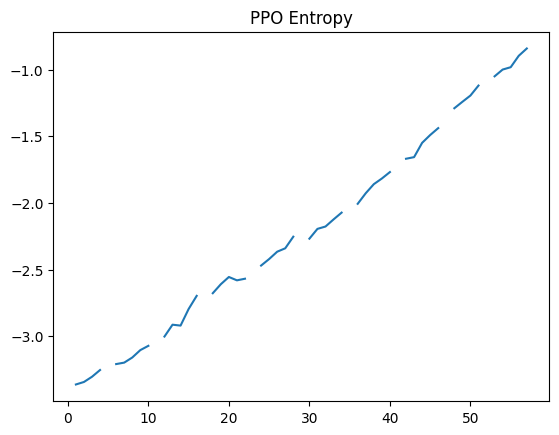

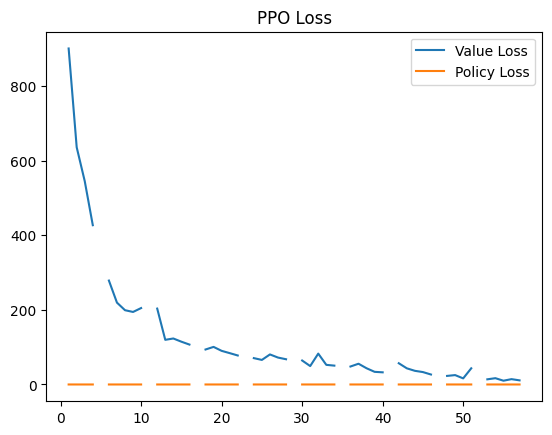

In [70]:
df = pd.read_csv("logs/ppo/progress.csv")

plt.plot(df["train/entropy_loss"])
plt.title("PPO Entropy")
plt.show()

plt.plot(df["train/value_loss"], label="Value Loss")
plt.plot(df["train/policy_gradient_loss"], label="Policy Loss")
plt.legend()
plt.title("PPO Loss")
plt.show()

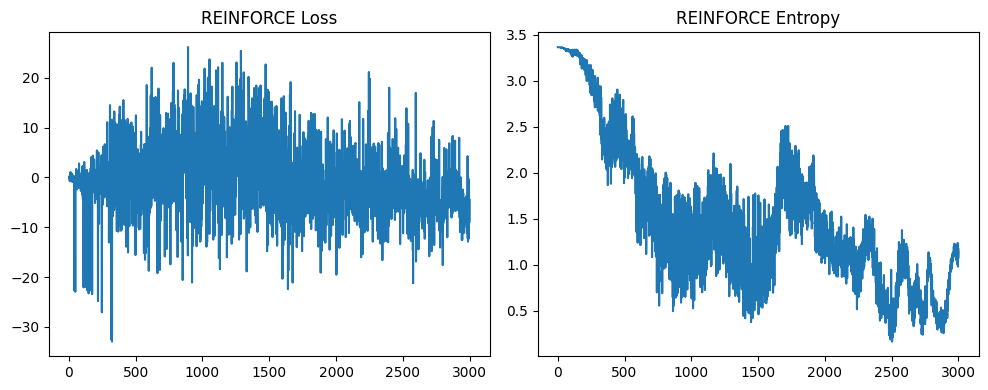

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logs/reinforce/progress.csv")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(df["episode"], df["loss"])
plt.title("REINFORCE Loss")

plt.subplot(1,2,2)
plt.plot(df["episode"], df["entropy"])
plt.title("REINFORCE Entropy")

plt.tight_layout()
plt.show()

In [58]:
def find_convergence(rewards, window=50, threshold=0.9):
    rolling = rewards.rolling(window).mean()
    max_val = rolling.max()

    for i in range(len(rolling)):
        if rolling[i] >= threshold * max_val:
            return i
    return None

In [66]:
import pandas as pd

dqn = pd.read_csv("logs/dqn/monitor.csv", comment='#')  # ignore lines starting with #
ppo = pd.read_csv("logs/ppo/monitor.csv")
reinforce = pd.read_csv("logs/reinforce/monitor.csv")

print(dqn.columns)
print(ppo.columns)
print(reinforce.columns)


Index(['r', 'l', 't'], dtype='object')
Index(['#{"t_start": 1775311724.411631', ' "env_id": "None"}'], dtype='object')
Index(['episode', 'reward'], dtype='object')


In [67]:
dqn = pd.read_csv("logs/dqn/monitor.csv", comment='#')["r"]
ppo = pd.read_csv("logs/ppo/monitor.csv", comment='#')["r"]
reinforce = pd.read_csv("logs/reinforce/monitor.csv", comment='#')["reward"]

print("DQN converges at:", find_convergence(dqn))
print("PPO converges at:", find_convergence(ppo))
print("REINFORCE converges at:", find_convergence(reinforce))

DQN converges at: 2819
PPO converges at: 79
REINFORCE converges at: 2874


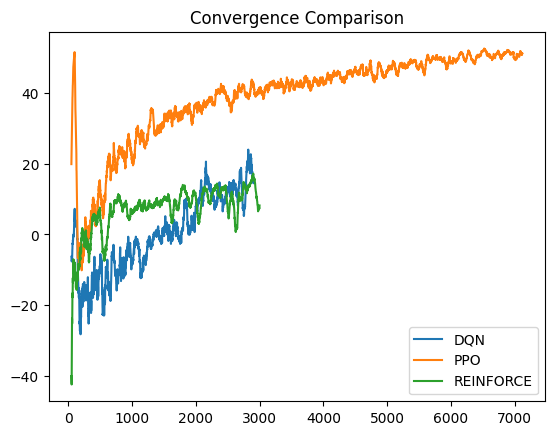

In [68]:
plt.plot(dqn.rolling(50).mean(), label="DQN")
plt.plot(ppo.rolling(50).mean(), label="PPO")
plt.plot(reinforce.rolling(50).mean(), label="REINFORCE")

plt.legend()
plt.title("Convergence Comparison")
plt.show()

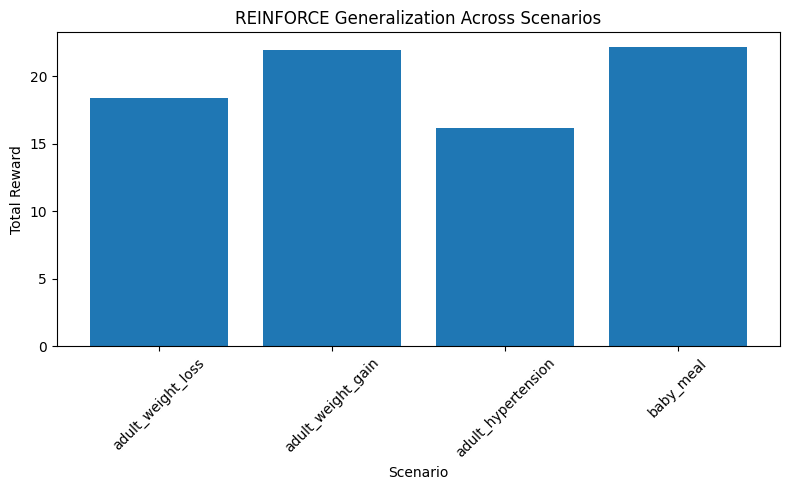


Detailed Results:
adult_weight_loss: 18.40
adult_weight_gain: 21.98
adult_hypertension: 16.17
baby_meal: 22.17


In [42]:
import torch
import matplotlib.pyplot as plt

from environment.custom_env import KitchenMealPlanningEnv

# Define scenarios (missing before)
SCENARIOS = [
    "adult_weight_loss",
    "adult_weight_gain",
    "adult_hypertension",
    "baby_meal",
]

def evaluate(model, device):
    results = {}

    for scenario in SCENARIOS:
        env = KitchenMealPlanningEnv()
        obs, _ = env.reset(options={"scenario_name": scenario})

        done = False
        truncated = False
        total = 0

        while not (done or truncated):
            obs_tensor = torch.tensor(
                obs, dtype=torch.float32, device=device
            ).unsqueeze(0)

            dist = model(obs_tensor)
            action = torch.argmax(dist.probs, dim=1).item()

            obs, r, done, truncated, _ = env.step(action)
            total += r

        results[scenario] = total

    return results


# Run evaluation
results = evaluate(model, device)

# Plot results
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("REINFORCE Generalization Across Scenarios")
plt.ylabel("Total Reward")
plt.xlabel("Scenario")
plt.tight_layout()
plt.show()

# Optional: print results clearly
print("\nDetailed Results:")
for k, v in results.items():
    print(f"{k}: {v:.2f}")

In [72]:
def evaluate_sb3(model):
    results = {}

    for scenario in SCENARIOS:
        env = KitchenMealPlanningEnv()
        obs, _ = env.reset(options={"scenario_name": scenario})

        done = False
        truncated = False
        total = 0

        while not (done or truncated):
            action, _ = model.predict(obs)
            obs, r, done, truncated, _ = env.step(action)
            total += r

        results[scenario] = total

    return results

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


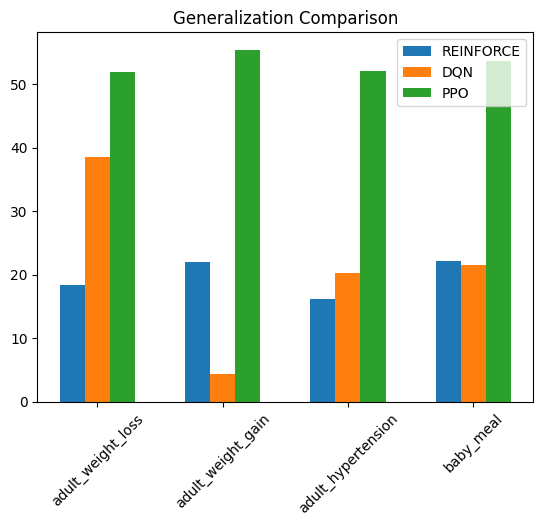

In [74]:
from stable_baselines3 import DQN, PPO

# Load DQN and PPO models
dqn_model = DQN.load("best_models/dqn/best_model.zip")
ppo_model = PPO.load("best_models/ppo/best_model.zip")

from stable_baselines3 import DQN, PPO

# Load DQN and PPO models
dqn_model = DQN.load("best_models/dqn/best_model.zip")
ppo_model = PPO.load("best_models/ppo/best_model.zip")


reinforce_res = evaluate(model, device)
dqn_res = evaluate_sb3(dqn_model)
ppo_res = evaluate_sb3(ppo_model)

import numpy as np

labels = list(reinforce_res.keys())
x = np.arange(len(labels))

plt.bar(x - 0.2, reinforce_res.values(), 0.2, label="REINFORCE")
plt.bar(x, dqn_res.values(), 0.2, label="DQN")
plt.bar(x + 0.2, ppo_res.values(), 0.2, label="PPO")

plt.xticks(x, labels, rotation=45)
plt.legend()
plt.title("Generalization Comparison")
plt.show()

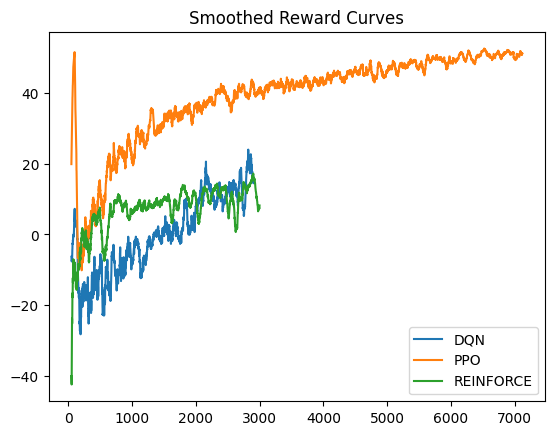

In [75]:
def smooth(x, window=50):
    return x.rolling(window).mean()

plt.plot(smooth(dqn), label="DQN")
plt.plot(smooth(ppo), label="PPO")
plt.plot(smooth(reinforce), label="REINFORCE")

plt.legend()
plt.title("Smoothed Reward Curves")
plt.show()

In [43]:
!pwd
!ls

/kaggle/working
analysis     environment  main.py  random_play.py    results
best_models  logs	  models   requirements.txt  training


In [44]:
!zip -r meal_project.zip analysis environment  main.py  random_play.py  results best_models  logs models   requirements.txt  training

  adding: analysis/ (stored 0%)
  adding: analysis/plot_results.py (deflated 59%)
  adding: environment/ (stored 0%)
  adding: environment/rendering.py (deflated 69%)
  adding: environment/custom_env.py (deflated 81%)
  adding: environment/__pycache__/ (stored 0%)
  adding: environment/__pycache__/rendering.cpython-312.pyc (deflated 52%)
  adding: environment/__pycache__/custom_env.cpython-312.pyc (deflated 56%)
  adding: main.py (deflated 61%)
  adding: random_play.py (deflated 50%)
  adding: results/ (stored 0%)
  adding: results/random_frames/ (stored 0%)
  adding: results/random_frames/frame_009.png (deflated 6%)
  adding: results/random_frames/frame_008.png (deflated 6%)
  adding: results/random_frames/frame_011.png (deflated 5%)
  adding: results/random_frames/frame_006.png (deflated 6%)
  adding: results/random_frames/frame_012.png (deflated 6%)
  adding: results/random_frames/frame_010.png (deflated 5%)
  adding: results/random_frames/frame_001.png (deflated 5%)
  adding: resul

In [45]:
from IPython.display import FileLink
FileLink('meal_project.zip')

/kaggle/working/meal_project.zip